# Comparaison automatique V1->V4 -- Stroke Risk Prediction
### NHANES | Ping Wang 2024 | DOI: 10.17632/xggs239bnw.1

**Dataset par pipeline (detecte via `feature_names_in_`) :**
- V1 + V2 : `data.csv` (35 colonnes -- ColumnTransformer V2 filtre en interne)
- V3 + V4 : `df_features.csv` (17 colonnes preprocessees)

> Metrique prioritaire : **Recall** -- minimiser les AVC non detectes (faux negatifs).

## 1. Imports

In [1]:
import pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    accuracy_score, roc_auc_score, confusion_matrix
)
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':'white', 'axes.facecolor':'white',
    'axes.grid':True, 'grid.alpha':0.3, 'grid.linestyle':'--',
    'font.family':'DejaVu Sans',
    'axes.spines.top':False, 'axes.spines.right':False,
})
print('Imports OK.')

Imports OK.


## 2. Configuration -- chemins a adapter

In [2]:
TARGET       = 'stroke'
RANDOM_STATE = 42
TEST_SIZE    = 0.20

DATA_RAW      = '../dataset/data.csv'
DATA_FEATURES = '../dataset/data_clean/df_features.csv'

VERSIONS = {
    'V1 -- Baseline'         : {
        'pipeline' : '../notebook_v1/pipeline_v1.pkl',
        'features' : '../notebook_v1/features_v1.pkl',
    },
    'V2 -- Feature selection': {
        'pipeline' : '../notebook_v2/pipeline_v2.pkl',
        'features' : '../notebook_v2/features_v2.pkl',
    },
    'V3 -- SMOTE'            : {
        'pipeline' : '../notebook_v3/pipeline_v3.pkl',
        'features' : '../notebook_v3/features_v3.pkl',
    },
    'V4 -- ADASYN'           : {
        'pipeline' : '../notebook_v4/pipeline_v4.pkl',
        'features' : '../notebook_v4/features_v4.pkl',
    },
}

THRESHOLDS = np.arange(0.05, 0.96, 0.05).round(2)

print('Configuration OK.')
print(f'  Versions : {list(VERSIONS.keys())}')

Configuration OK.
  Versions : ['V1 -- Baseline', 'V2 -- Feature selection', 'V3 -- SMOTE', 'V4 -- ADASYN']


## 3. Chargement des donnees

- `X_test_raw` (35 cols) -> V1 et V2
- `X_test_feat` (17 cols) -> V3 et V4

In [3]:
df_raw = pd.read_csv(DATA_RAW)
df_raw.columns = df_raw.columns.str.strip()
X_raw = df_raw.drop(columns=[TARGET])
y_raw = df_raw[TARGET]
_, X_test_raw, _, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=TEST_SIZE, stratify=y_raw, random_state=RANDOM_STATE
)
print(f'data.csv        : {df_raw.shape} | X_test_raw  : {X_test_raw.shape}')
print(f'Stroke y_test_raw  : {int(y_test_raw.sum())} / {len(y_test_raw)}')

df_feat = pd.read_csv(DATA_FEATURES)
df_feat.columns = df_feat.columns.str.strip()
X_feat = df_feat.drop(columns=[TARGET])
y_feat = df_feat[TARGET]
_, X_test_feat, _, y_test_feat = train_test_split(
    X_feat, y_feat, test_size=TEST_SIZE, stratify=y_feat, random_state=RANDOM_STATE
)
print(f'df_features.csv : {df_feat.shape} | X_test_feat : {X_test_feat.shape}')
print(f'Stroke y_test_feat : {int(y_test_feat.sum())} / {len(y_test_feat)}')

assert y_test_raw.sum() == y_test_feat.sum(), 'ERREUR : nb stroke different !'
print(f'OK : {int(y_test_raw.sum())} stroke dans les deux y_test.')

data.csv        : (4603, 36) | X_test_raw  : (921, 35)
Stroke y_test_raw  : 72 / 921
df_features.csv : (4603, 18) | X_test_feat : (921, 17)
Stroke y_test_feat : 72 / 921
OK : 72 stroke dans les deux y_test.


## 4. Fonction d'evaluation automatique

Detection du bon dataset via `n_features_in_` du premier step du pipeline.
Ordre des colonnes garanti via `feature_names_in_`.

In [4]:
def evaluate_version(name, pipeline_path, features_path,
                     X_test_raw, y_test_raw,
                     X_test_feat, y_test_feat,
                     thresholds):

    with open(pipeline_path, 'rb') as f:
        pipeline = pickle.load(f)
    with open(features_path, 'rb') as f:
        features = pickle.load(f)

    model_name = type(pipeline.named_steps['model']).__name__

    # Detection automatique : n_features_in_ du premier step
    first_step    = pipeline.steps[0][1]
    n_expected    = getattr(first_step, 'n_features_in_', len(features))
    cols_expected = list(getattr(first_step, 'feature_names_in_', features))

    if n_expected == 35:
        X_test, y_test = X_test_raw, y_test_raw
        dataset_used   = 'data.csv (35 cols)'
    else:
        X_test, y_test = X_test_feat, y_test_feat
        dataset_used   = 'df_features.csv (17 cols)'

    # Verifier colonnes disponibles
    missing = set(cols_expected) - set(X_test.columns)
    if missing:
        raise ValueError(f'{name} : colonnes manquantes : {missing}')

    # Passer les colonnes dans l'ordre exact du fit
    X_v   = X_test[cols_expected]
    proba = pipeline.predict_proba(X_v)[:, 1]
    auc   = roc_auc_score(y_test, proba)

    best = {'f1': -1}
    curve_rows = []

    for t in thresholds:
        y_pred = (proba >= t).astype(int)
        rec  = recall_score(y_test, y_pred, zero_division=0)
        prec = precision_score(y_test, y_pred, zero_division=0)
        f1   = f1_score(y_test, y_pred, zero_division=0)
        acc  = accuracy_score(y_test, y_pred)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        row = {'threshold': t, 'recall': rec, 'precision': prec,
               'f1': f1, 'accuracy': acc,
               'fn': int(fn), 'fp': int(fp), 'tp': int(tp), 'tn': int(tn)}
        curve_rows.append(row)
        if f1 > best['f1']:
            best = row.copy()

    return {
        'name'      : name,
        'model'     : model_name,
        'n_features': len(features),
        'features'  : features,
        'dataset'   : dataset_used,
        'auc'       : auc,
        'best'      : best,
        'curve'     : pd.DataFrame(curve_rows),
        'n_test'    : len(y_test),
        'n_stroke'  : int(y_test.sum()),
    }

print('evaluate_version() definie -- detection automatique dataset + ordre colonnes OK.')

evaluate_version() definie -- detection automatique dataset + ordre colonnes OK.


## 5. Evaluation automatique des 4 versions

In [5]:
results = {}

for name, cfg in VERSIONS.items():
    print(f'  {name} ...', end=' ')
    results[name] = evaluate_version(
        name,
        cfg['pipeline'], cfg['features'],
        X_test_raw, y_test_raw,
        X_test_feat, y_test_feat,
        THRESHOLDS
    )
    r = results[name]
    print(f"OK | {r['model']} | {r['dataset']} | "
          f"recall={r['best']['recall']*100:.1f}% | "
          f"seuil={r['best']['threshold']:.2f} | "
          f"AUC={r['auc']:.4f}")

print(f'\nToutes les versions evaluees. results contient {len(results)} entrees.')

  V1 -- Baseline ... OK | LogisticRegression | data.csv (35 cols) | recall=0.0% | seuil=0.05 | AUC=0.4887
  V2 -- Feature selection ... OK | LogisticRegression | data.csv (35 cols) | recall=62.5% | seuil=0.05 | AUC=0.5938
  V3 -- SMOTE ... OK | XGBClassifier | df_features.csv (17 cols) | recall=30.6% | seuil=0.55 | AUC=0.5355
  V4 -- ADASYN ... OK | LogisticRegression | df_features.csv (17 cols) | recall=95.8% | seuil=0.10 | AUC=0.5033

Toutes les versions evaluees. results contient 4 entrees.


## 6. Tableau recapitulatif -- seuil optimal par version

In [6]:
rows = []
for name, res in results.items():
    b = res['best']
    rows.append({
        'Version'   : name,
        'Modele'    : res['model'],
        'Dataset'   : res['dataset'],
        'Features'  : res['n_features'],
        'Seuil'     : round(b['threshold'], 2),
        'Recall'    : round(b['recall']*100, 1),
        'Precision' : round(b['precision']*100, 1),
        'F1'        : round(b['f1']*100, 1),
        'Accuracy'  : round(b['accuracy']*100, 1),
        'AUC_ROC'   : round(res['auc'], 4),
        'FN'        : b['fn'],
        'FP'        : b['fp'],
    })

df_summary = pd.DataFrame(rows)

def color_recall(val):
    if val >= 60:   return 'background-color:#d4edda;color:#155724;font-weight:bold'
    elif val >= 20: return 'background-color:#fff3cd;color:#856404'
    else:           return 'background-color:#f8d7da;color:#721c24'

def color_fn(val):
    if val <= 10:   return 'background-color:#d4edda;color:#155724;font-weight:bold'
    elif val <= 25: return 'background-color:#fff3cd;color:#856404'
    else:           return 'background-color:#f8d7da;color:#721c24'

print('=== TABLEAU RECAPITULATIF -- SEUIL OPTIMAL PAR VERSION ===')
display(df_summary.style
        .applymap(color_recall, subset=['Recall'])
        .applymap(color_fn,     subset=['FN'])
        .format({
            'Recall'   : '{:.1f}%',
            'Precision': '{:.1f}%',
            'F1'       : '{:.1f}%',
            'Accuracy' : '{:.1f}%',
            'Seuil'    : '{:.2f}',
            'AUC_ROC'  : '{:.4f}',
        })
        .hide(axis='index'))

=== TABLEAU RECAPITULATIF -- SEUIL OPTIMAL PAR VERSION ===


Version,Modele,Dataset,Features,Seuil,Recall,Precision,F1,Accuracy,AUC_ROC,FN,FP
V1 -- Baseline,LogisticRegression,data.csv (35 cols),35,0.05,0.0%,0.0%,0.0%,92.2%,0.4887,72,0
V2 -- Feature selection,LogisticRegression,data.csv (35 cols),17,0.05,62.5%,9.3%,16.2%,49.6%,0.5938,27,437
V3 -- SMOTE,XGBClassifier,df_features.csv (17 cols),17,0.55,30.6%,10.3%,15.4%,73.7%,0.5355,50,192
V4 -- ADASYN,LogisticRegression,df_features.csv (17 cols),17,0.10,95.8%,8.1%,15.0%,14.8%,0.5033,3,782


## 7. Graphique comparaison complete -- tout sur X_test

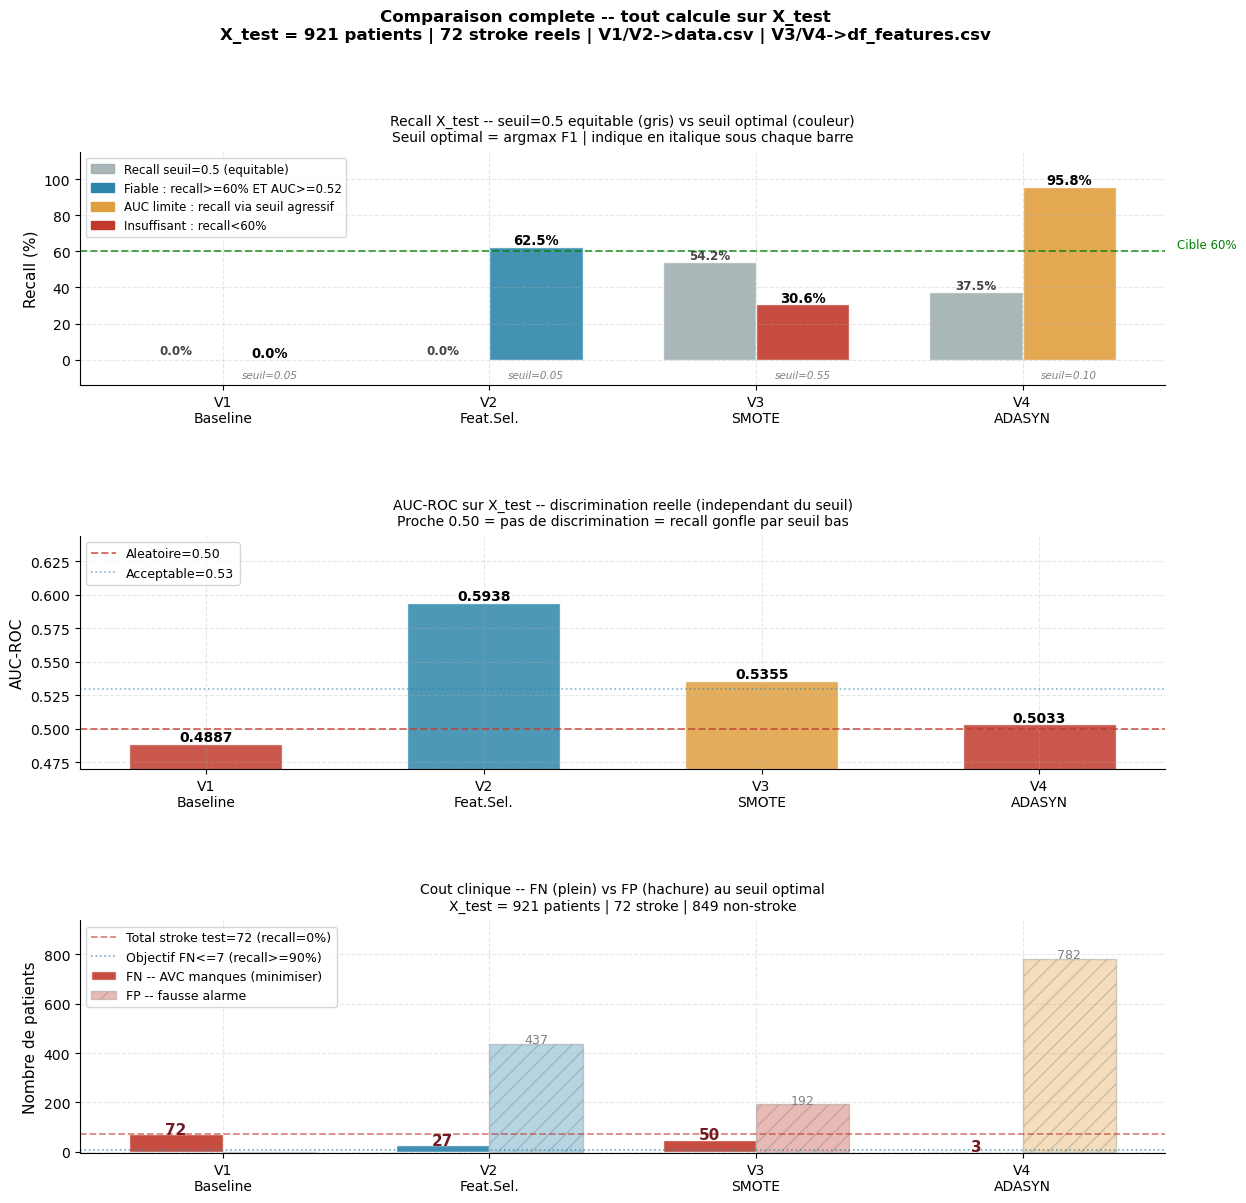

Figure sauvegardee : fig_comparaison_complete_xtest.png


In [7]:
version_names   = list(results.keys())
short_v         = ['V1\nBaseline', 'V2\nFeat.Sel.', 'V3\nSMOTE', 'V4\nADASYN']
recall_opt_vals = [results[v]['best']['recall']*100  for v in version_names]
thresh_opt_vals = [results[v]['best']['threshold']   for v in version_names]
auc_vals        = [results[v]['auc']                 for v in version_names]
fn_vals         = [results[v]['best']['fn']          for v in version_names]
fp_vals         = [results[v]['best']['fp']          for v in version_names]
n_stroke        = results[version_names[0]]['n_stroke']
n_test          = results[version_names[0]]['n_test']

# Recall seuil fixe 0.5 depuis la courbe
recall_05_vals = []
for v in version_names:
    row = results[v]['curve'][results[v]['curve']['threshold'] == 0.50]
    recall_05_vals.append(float(row['recall'].values[0])*100 if len(row) > 0 else 0.0)

def bar_color(rec, auc):
    if rec >= 60 and auc >= 0.52: return '#2E86AB'
    elif rec >= 60:               return '#E09F3E'
    else:                         return '#C0392B'

colors = [bar_color(r, a) for r, a in zip(recall_opt_vals, auc_vals)]
x = np.arange(len(version_names)); w = 0.35

fig = plt.figure(figsize=(14, 13))
gs  = gridspec.GridSpec(3, 1, figure=fig, hspace=0.65)
ax1, ax2, ax3 = [fig.add_subplot(gs[i]) for i in range(3)]

fig.suptitle(
    'Comparaison complete -- tout calcule sur X_test\n'
    f'X_test = {n_test} patients | {n_stroke} stroke reels | '
    'V1/V2->data.csv | V3/V4->df_features.csv',
    fontsize=12, fontweight='bold', y=0.99
)

# ── Plot 1 : Recall seuil=0.5 vs seuil optimal ────────────────────────────
ax1.bar(x - w/2, recall_05_vals,  w, color='#95A5A6', alpha=0.80, edgecolor='white')
ax1.bar(x + w/2, recall_opt_vals, w, color=colors,    alpha=0.90, edgecolor='white')

for xi, val in zip(x, recall_05_vals):
    ax1.text(xi-w/2, max(val+1.5, 3.0), f'{val:.1f}%',
             ha='center', fontsize=8.5, color='#444', fontweight='bold')
for xi, val, t in zip(x, recall_opt_vals, thresh_opt_vals):
    ax1.text(xi+w/2, val+1.5, f'{val:.1f}%',
             ha='center', fontsize=9.5, fontweight='bold')
    ax1.text(xi+w/2, -10, f'seuil={t:.2f}',
             ha='center', fontsize=7.5, color='gray', style='italic')

ax1.axhline(60, color='green', linestyle='--', linewidth=1.4, alpha=0.7)
ax1.text(len(version_names)-0.42, 62, 'Cible 60%', fontsize=8.5, color='green')
ax1.set_xticks(x); ax1.set_xticklabels(short_v, fontsize=10)
ax1.set_ylabel('Recall (%)', fontsize=11); ax1.set_ylim(-14, 115)
ax1.set_title(
    'Recall X_test -- seuil=0.5 equitable (gris) vs seuil optimal (couleur)\n'
    'Seuil optimal = argmax F1 | indique en italique sous chaque barre',
    fontsize=10, pad=8)
ax1.legend(handles=[
    mpatches.Patch(color='#95A5A6', alpha=0.8, label='Recall seuil=0.5 (equitable)'),
    mpatches.Patch(color='#2E86AB', label='Fiable : recall>=60% ET AUC>=0.52'),
    mpatches.Patch(color='#E09F3E', label='AUC limite : recall via seuil agressif'),
    mpatches.Patch(color='#C0392B', label='Insuffisant : recall<60%'),
], fontsize=8.5, loc='upper left')

# ── Plot 2 : AUC-ROC ──────────────────────────────────────────────────────
auc_clrs = ['#2E86AB' if a>=0.55 else '#E09F3E' if a>=0.52 else '#C0392B' for a in auc_vals]
ax2.bar(x, auc_vals, 0.55, color=auc_clrs, alpha=0.85, edgecolor='white')
for xi, val in zip(x, auc_vals):
    ax2.text(xi, val+0.002, f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
ax2.axhline(0.50, color='#C0392B', linestyle='--', linewidth=1.4, alpha=0.7, label='Aleatoire=0.50')
ax2.axhline(0.53, color='#2E86AB', linestyle=':',  linewidth=1.2, alpha=0.6, label='Acceptable=0.53')
ax2.set_xticks(x); ax2.set_xticklabels(short_v, fontsize=10)
ax2.set_ylabel('AUC-ROC', fontsize=11); ax2.set_ylim(0.47, max(auc_vals)+0.05)
ax2.set_title(
    'AUC-ROC sur X_test -- discrimination reelle (independant du seuil)\n'
    'Proche 0.50 = pas de discrimination = recall gonfle par seuil bas',
    fontsize=10, pad=8)
ax2.legend(fontsize=9, loc='upper left')

# ── Plot 3 : FN et FP ─────────────────────────────────────────────────────
ax3.bar(x-w/2, fn_vals, w, color=colors, alpha=0.90, edgecolor='white',
         label='FN -- AVC manques (minimiser)')
ax3.bar(x+w/2, fp_vals, w, color=colors, alpha=0.35, edgecolor='gray',
         hatch='//', label='FP -- fausse alarme')
for xi, fn, fp in zip(x, fn_vals, fp_vals):
    ax3.text(xi-w/2, fn+2, str(fn), ha='center', fontsize=11,
             fontweight='bold', color='#721c24')
    if fp > 0:
        ax3.text(xi+w/2, fp+2, str(fp), ha='center', fontsize=9, color='gray')
ax3.axhline(n_stroke, color='#C0392B', linestyle='--', linewidth=1.3, alpha=0.6,
             label=f'Total stroke test={n_stroke} (recall=0%)')
ax3.axhline(int(n_stroke*0.10), color='#2E86AB', linestyle=':', linewidth=1.2, alpha=0.7,
             label=f'Objectif FN<={int(n_stroke*0.10)} (recall>=90%)')
ax3.set_xticks(x); ax3.set_xticklabels(short_v, fontsize=10)
ax3.set_ylabel('Nombre de patients', fontsize=11)
ax3.set_ylim(-5, max(fp_vals)*1.20 if max(fp_vals) > 0 else 10)
ax3.set_title(
    f'Cout clinique -- FN (plein) vs FP (hachure) au seuil optimal\n'
    f'X_test = {n_test} patients | {n_stroke} stroke | {n_test-n_stroke} non-stroke',
    fontsize=10, pad=8)
ax3.legend(fontsize=9, loc='upper left')

plt.savefig('fig_comparaison_complete_xtest.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Figure sauvegardee : fig_comparaison_complete_xtest.png')

## 8. Courbes Recall / Accuracy / F1 selon le seuil -- V3 et V4

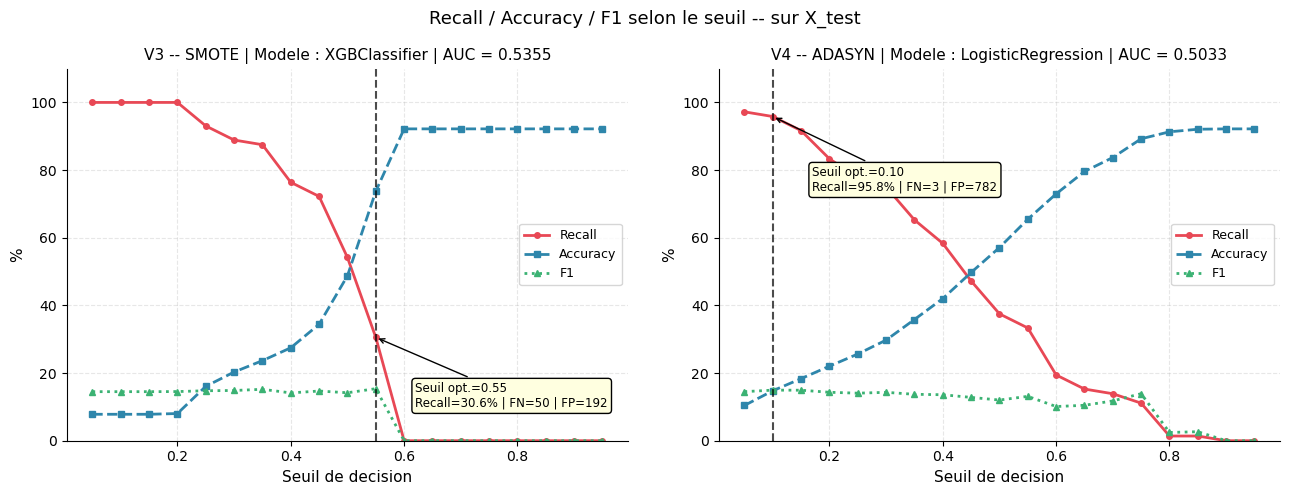

Figure sauvegardee : fig_threshold_curves.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, vname in zip(axes, ['V3 -- SMOTE', 'V4 -- ADASYN']):
    if vname not in results:
        ax.text(0.5, 0.5, f'{vname} non trouve', ha='center',
                va='center', transform=ax.transAxes)
        continue
    curve = results[vname]['curve']
    best  = results[vname]['best']
    ax.plot(curve['threshold'], curve['recall']*100,
            color='#E84855', linewidth=2, marker='o', markersize=4, label='Recall')
    ax.plot(curve['threshold'], curve['accuracy']*100,
            color='#2E86AB', linewidth=2, marker='s', markersize=4,
            label='Accuracy', linestyle='--')
    ax.plot(curve['threshold'], curve['f1']*100,
            color='#3BB273', linewidth=2, marker='^', markersize=4,
            label='F1', linestyle=':')
    ax.axvline(best['threshold'], color='black', linestyle='--',
               linewidth=1.5, alpha=0.7)
    yt = best['recall']*100
    xt = best['threshold']
    xt2 = min(xt+0.07, 0.85)
    ax.annotate(
        f"Seuil opt.={xt:.2f}\n"
        f"Recall={yt:.1f}% | FN={best['fn']} | FP={best['fp']}",
        xy=(xt, yt), xytext=(xt2, max(yt-22, 10)),
        arrowprops=dict(arrowstyle='->', color='black'),
        fontsize=8.5,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow')
    )
    ax.set_xlabel('Seuil de decision', fontsize=11)
    ax.set_ylabel('%', fontsize=11)
    ax.set_title(
        f'{vname} | Modele : {results[vname]["model"]} | '
        f'AUC = {results[vname]["auc"]:.4f}',
        fontsize=11)
    ax.set_ylim(0, 110)
    ax.legend(fontsize=9)

plt.suptitle('Recall / Accuracy / F1 selon le seuil -- sur X_test', fontsize=13)
plt.tight_layout()
plt.savefig('fig_threshold_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardee : fig_threshold_curves.png')

## 9. Verdict automatique -- base sur X_test

In [9]:
version_names = list(results.keys())

best_recall_v = max(version_names, key=lambda v: results[v]['best']['recall'])
best_auc_v    = max(version_names, key=lambda v: results[v]['auc'])
best_fn_v     = min(version_names, key=lambda v: results[v]['best']['fn'])

coherent = [
    v for v in version_names
    if results[v]['best']['recall']*100 >= 60 and results[v]['auc'] >= 0.52
]
best_coherent = (
    max(coherent, key=lambda v: results[v]['best']['recall'])
    if coherent else best_recall_v
)

print('=' * 70)
print(f'{"VERDICT -- BASE SUR X_TEST":^70}')
print('=' * 70)

for title, v in [
    ('Meilleur Recall X_test', best_recall_v),
    ('Meilleur AUC-ROC',       best_auc_v),
    ('Minimum FN (AVC)',        best_fn_v),
]:
    b = results[v]['best']
    print(f'\n  {title} : {v}')
    print(f'    Modele  = {results[v]["model"]} | {results[v]["dataset"]}')
    print(f'    Recall  = {b["recall"]*100:.1f}% (seuil={b["threshold"]:.2f})')
    print(f'    AUC-ROC = {results[v]["auc"]:.4f}')
    print(f'    FN      = {b["fn"]} AVC manques | FP = {b["fp"]} fausses alarmes')

bc = results[best_coherent]['best']
print(f'\n  >> RECOMMANDE (recall>=60% ET AUC>=0.52) :')
print(f'     Version : {best_coherent}')
print(f'     Modele  : {results[best_coherent]["model"]}')
print(f'     Dataset : {results[best_coherent]["dataset"]}')
print(f'     Seuil   : {bc["threshold"]:.2f}')
print(f'     Recall  : {bc["recall"]*100:.1f}%')
print(f'     AUC-ROC : {results[best_coherent]["auc"]:.4f}')
print(f'     FN      : {bc["fn"]} / {results[best_coherent]["n_stroke"]} AVC')
print(f'     FP      : {bc["fp"]} fausses alarmes')
print('=' * 70)

print()
print('NOTE : AUC-ROC ~0.50 sur V3/V4 = consequence attendue du SMOTE/ADASYN')
print('sur un desequilibre 92/8%. Recall eleve = seuil bas + surechantillonnage,')
print('pas necessairement une meilleure discrimination. A documenter dans le rapport.')

                      VERDICT -- BASE SUR X_TEST                      

  Meilleur Recall X_test : V4 -- ADASYN
    Modele  = LogisticRegression | df_features.csv (17 cols)
    Recall  = 95.8% (seuil=0.10)
    AUC-ROC = 0.5033
    FN      = 3 AVC manques | FP = 782 fausses alarmes

  Meilleur AUC-ROC : V2 -- Feature selection
    Modele  = LogisticRegression | data.csv (35 cols)
    Recall  = 62.5% (seuil=0.05)
    AUC-ROC = 0.5938
    FN      = 27 AVC manques | FP = 437 fausses alarmes

  Minimum FN (AVC) : V4 -- ADASYN
    Modele  = LogisticRegression | df_features.csv (17 cols)
    Recall  = 95.8% (seuil=0.10)
    AUC-ROC = 0.5033
    FN      = 3 AVC manques | FP = 782 fausses alarmes

  >> RECOMMANDE (recall>=60% ET AUC>=0.52) :
     Version : V2 -- Feature selection
     Modele  : LogisticRegression
     Dataset : data.csv (35 cols)
     Seuil   : 0.05
     Recall  : 62.5%
     AUC-ROC : 0.5938
     FN      : 27 / 72 AVC
     FP      : 437 fausses alarmes

NOTE : AUC-ROC ~0.50 sur